## Step 0: Install Required Libraries

In [4]:
# Install required libraries for Word2Vec / GloVe
!pip install numpy==1.23.5 -q
!pip install gensim -q
print("Libraries installed. Please RESTART RUNTIME if prompted, then re-run from Step 1.")

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Libraries installed. Please RESTART RUNTIME if prompted, then re-run from Step 1.


## Step 1: Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input

# Gensim
import gensim.downloader as api

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Step 2: Load Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
csv_path = '/content/drive/MyDrive/AI/assessment/spam/data/spamvsham.csv'
df = pd.read_csv(csv_path, encoding='latin-1', usecols=['v1', 'v2'])
df.columns = ['label', 'content']  # rename to something cleaner
print("Shape:", df.shape)
df.head(5)

Shape: (5572, 2)


,label,content
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3: Data Understanding & Exploratory Analysis

In [8]:
# ── Basic Info ─────────────────────────────────────────────────────────────
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Class Distribution ===")
print(df['label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   content  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

=== Missing Values ===
label      0
content    0
dtype: int64

=== Class Distribution ===
label
ham     4825
spam     747
Name: count, dtype: int64


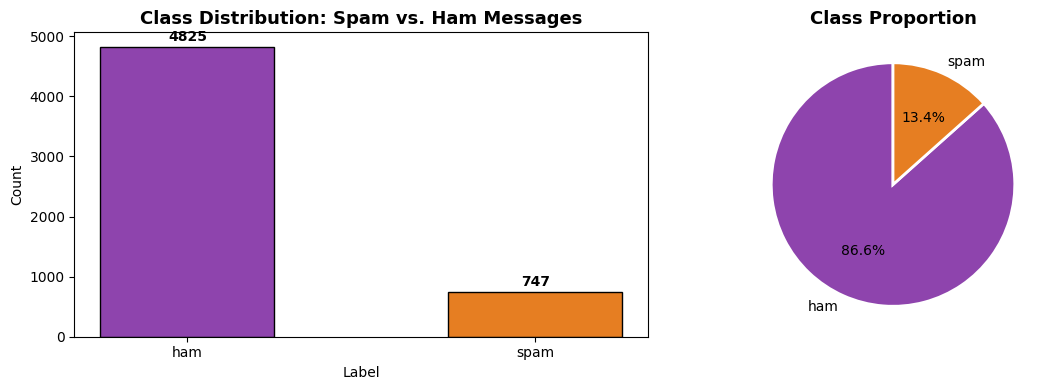

Dataset is imbalanced: 4,825 ham messages and 747 spam messages.


In [39]:
# ── Class Distribution Bar Plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['label'].value_counts()
colors = ['#8e44ad', '#e67e22']

axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution: Spam vs. Ham Messages', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is imbalanced: 4,825 ham messages and 747 spam messages.")

=== Text Length Statistics ===
        count       mean        std  min   25%   50%   75%    max
label                                                            
ham    4825.0  14.200622  11.424511  1.0   7.0  11.0  19.0  171.0
spam    747.0  23.851406   5.811898  2.0  22.0  25.0  28.0   35.0


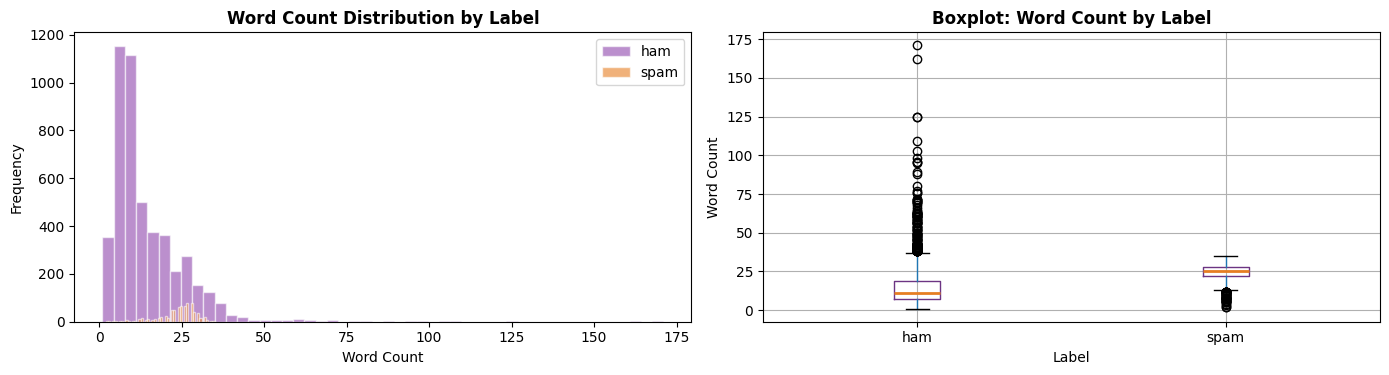

In [42]:
# ── Text Length Analysis ────────────────────────────────────────────────────
df['text_length'] = df['content'].apply(lambda x: len(str(x).split()))

print("=== Text Length Statistics ===")
print(df.groupby('label')['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(['ham', 'spam'], ['#8e44ad', '#e67e22']):
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Word Count Distribution by Label', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df.boxplot(column='text_length', by='label', ax=axes[1],
           boxprops=dict(color='#6c3483'),
           medianprops=dict(color='#e67e22', linewidth=2))
axes[1].set_title('Boxplot: Word Count by Label', fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Text Preprocessing & Cleaning

In [11]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Common contractions dictionary
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not", "isn't": "is not", "aren't": "are not",
    "wasn't": "was not", "weren't": "were not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "I'm": "I am",
    "I've": "I have", "I'll": "I will", "I'd": "I would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "we're": "we are", "you're": "you are",
    "he's": "he is", "she's": "she is", "let's": "let us",
    "can't": "cannot", "I'M": "I am"
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    text = str(text).lower()                             # Lowercase
    text = expand_contractions(text)                     # Expand contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)        # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove mentions
    text = re.sub(r'#\w+', '', text)                     # Remove hashtags
    text = re.sub(r'\d+', '', text)                      # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)                  # Remove punctuation / special chars
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS] # Remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # Lemmatize
    return ' '.join(tokens)

print("Cleaning text... (this may take 1-2 minutes)")
df['cleaned_content'] = df['content'].apply(clean_text)
print("Done!")

print("\n=== Sample: Original vs. Cleaned ===")
for i in range(2):
    print(f"\n[{df['label'].iloc[i].upper()}]")
    print("Original:", df['content'].iloc[i][:200])
    print("Cleaned :", df['cleaned_content'].iloc[i][:200])

Cleaning text... (this may take 1-2 minutes)
Done!

=== Sample: Original vs. Cleaned ===

[HAM]
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go jurong point crazy available bugis n great world la e buffet cine got amore wat

[HAM]
Original: Ok lar... Joking wif u oni...
Cleaned : ok lar joking wif u oni


## Step 5: Visualize Cleaned Data

In [12]:
# Run this first to debug
print("Columns:", df.columns.tolist())
print("Label values:", df['label'].unique())
print("Null cleaned_content:", df['cleaned_content'].isna().sum())
print("Empty cleaned_content:", (df['cleaned_content'] == '').sum())

# Check what a filtered subset looks like
ham_df = df[df['label'] == 'ham']
print("\nHam rows:", len(ham_df))
print("Sample cleaned_content:", ham_df['cleaned_content'].iloc[0])

Columns: ['label', 'content', 'text_length', 'cleaned_content']
Label values: ['ham' 'spam']
Null cleaned_content: 0
Empty cleaned_content: 6

Ham rows: 4825
Sample cleaned_content: go jurong point crazy available bugis n great world la e buffet cine got amore wat


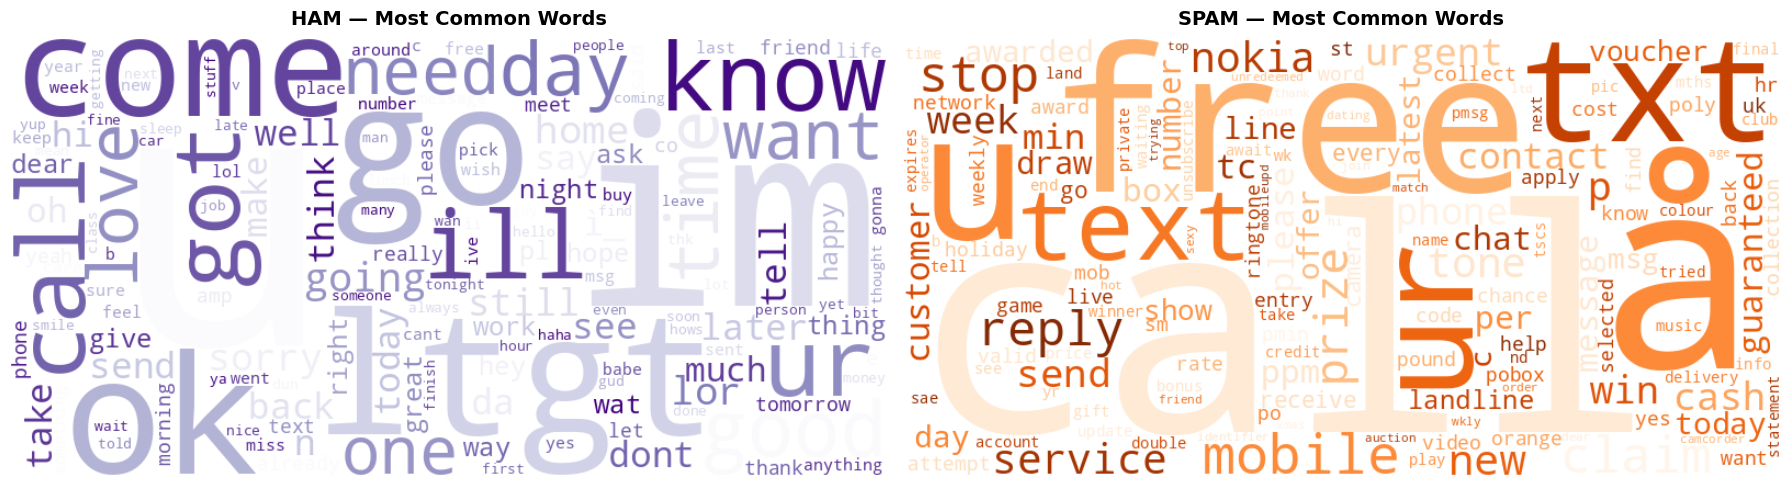

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, label, cmap, title in zip(
    axes,
    ['ham', 'spam'],                                          # ← fix here
    ['Purples', 'Oranges'],
    ['HAM — Most Common Words', 'SPAM — Most Common Words']  # ← and here
):
    corpus = ' '.join(df[df['label'] == label]['cleaned_content'].tolist())
    wc = WordCloud(
        width=800, height=400, background_color='white',
        colormap=cmap, max_words=150, collocations=False
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

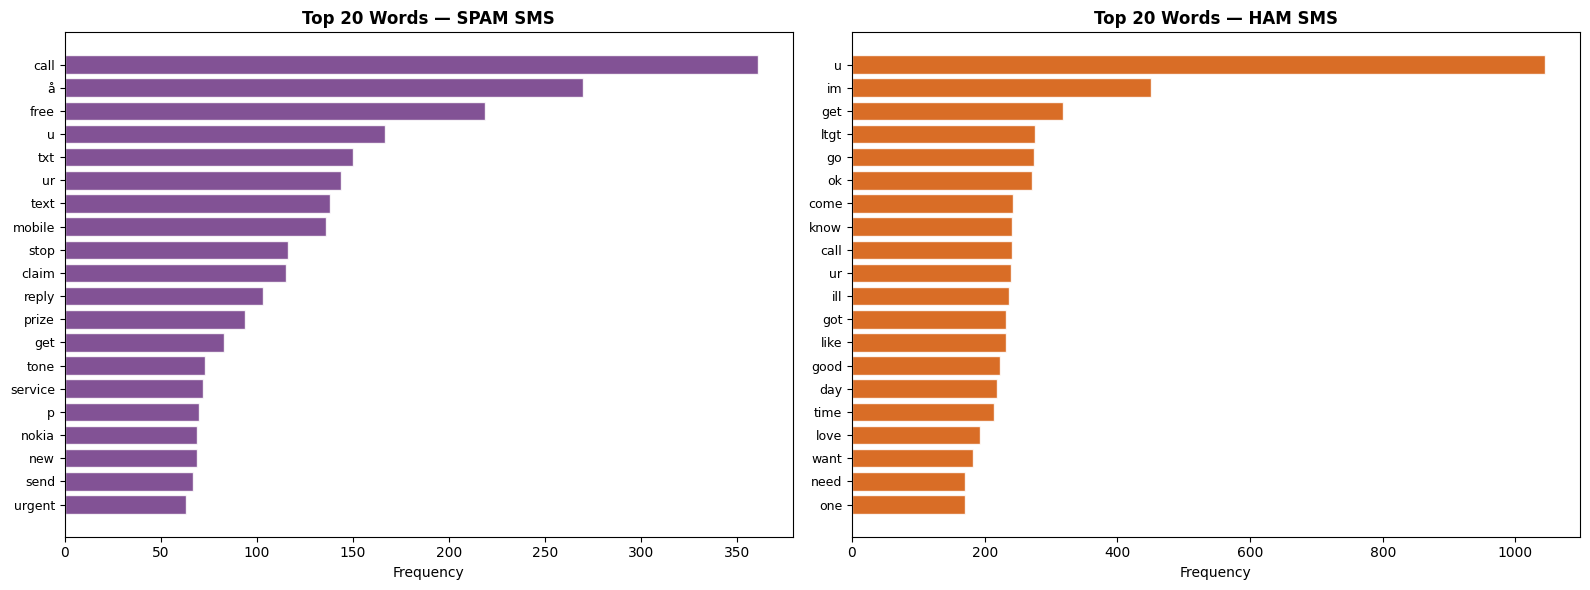

In [43]:
# ── Top 20 Most Frequent Words per Class ───────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['spam', 'ham'], ['#6c3483', '#d35400']):
    all_words = ' '.join(df[df['label'] == label]['cleaned_content']).split()
    word_freq = Counter(all_words).most_common(20)
    words, freqs = zip(*word_freq)

    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 20 Words — {label.upper()} SMS', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Tokenization, Train/Test Split & Sequence Padding

In [15]:
# ── Label Encoding ─────────────────────────────────────────────────────────
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned_content'].values
y = df['label_enc'].values

# ── Train / Test Split (80/20) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ── Tokenizer ──────────────────────────────────────────────────────────────
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)              # Fit only on training data

word_index = tokenizer.word_index
print(f"Vocabulary size (fitted): {len(word_index)}")

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based Padding ───────────────────────────────────────────────
train_lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(train_lengths, 95))   # 95th percentile
print(f"Max sequence length (95th percentile): {MAX_LEN} tokens")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")
# ── Class Weights (handles imbalance: ~5000 ham vs ~487 spam) ─────────────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print(f"Class weights: {class_weight}  (higher weight on minority spam class)")


Train size: 4457  |  Test size: 1115
Vocabulary size (fitted): 6985
Max sequence length (95th percentile): 20 tokens
X_train_pad shape: (4457, 20)
X_test_pad  shape: (1115, 20)
Class weights: {0: np.float64(0.577481212749417), 1: np.float64(3.7265886287625416)}  (higher weight on minority spam class)


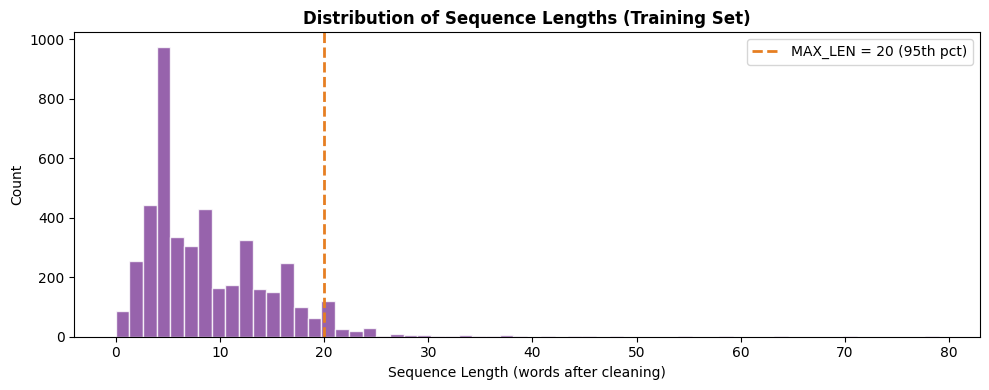

In [16]:
# ── Visualize sequence length distribution ─────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(train_lengths, bins=60, color='#7d3c98', edgecolor='white', alpha=0.8)
plt.axvline(MAX_LEN, color='#e67e22', linestyle='--', linewidth=2, label=f'MAX_LEN = {MAX_LEN} (95th pct)')
plt.title('Distribution of Sequence Lengths (Training Set)', fontweight='bold')
plt.xlabel('Sequence Length (words after cleaning)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Helper Functions

In [55]:
def plot_history(history, model_name, axes=None, show=True):
    """Plot training vs validation loss and accuracy."""
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f'{model_name} — Training History', fontsize=13, fontweight='bold')

    axes[0].plot(history.history['loss'],     label='Train Loss',      color='#5b2c8d')
    axes[0].plot(history.history['val_loss'], label='Val Loss',        color='#f39c12',  linestyle='--')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Acc',   color='#5b2c8d')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',     color='#f39c12',  linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    if show:
        plt.tight_layout()
        plt.savefig(f'{model_name.replace(" ","_")}_history.png', dpi=150, bbox_inches='tight')
        plt.show()


def evaluate_model(model, X_test_pad, y_test, model_name):
    """Evaluate and print metrics + confusion matrix."""
    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred



results = {}   # store results for comparison
print("Helper functions ready.")

Helper functions ready.


---
## Model 1: Simple RNN with Trainable Embedding

In [18]:
EMBEDDING_DIM = 64

tf.keras.backend.clear_session()

rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Input(shape=(MAX_LEN,)))                                    # ← add this
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)) # ← remove input_length
rnn_model.add(SimpleRNN(units=64, return_sequences=False))
rnn_model.add(Dropout(0.4))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,369 (4.92 MB)

 Trainable params: 1,290,369 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
callbacks_rnn = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_rnn_model.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Model 1: Simple RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks_rnn,
    class_weight=class_weight,
    verbose=1
)

Training Model 1: Simple RNN...
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7384 - loss: 0.5268

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8442 - loss: 0.3959 - val_accuracy: 0.9395 - val_loss: 0.2057
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9768 - loss: 0.1315 - val_accuracy: 0.9395 - val_loss: 0.1792
Epoch 3/15
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9940 - loss: 0.0538

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9930 - loss: 0.0479 - val_accuracy: 0.9596 - val_loss: 0.2545
Epoch 4/15
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9919 - loss: 0.0619

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9950 - loss: 0.0473 - val_accuracy: 0.9664 - val_loss: 0.1466
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9970 - loss: 0.0313 - val_accuracy: 0.9664 - val_loss: 0.0999
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9975 - loss: 0.0218 - val_accuracy: 0.9619 - val_loss: 0.1823
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9983 - loss: 0.0177 - val_accuracy: 0.9327 - val_loss: 0.2341
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9960 - loss: 0.0261 - val_accuracy: 0.9664 - val_loss: 0.1581
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 5.


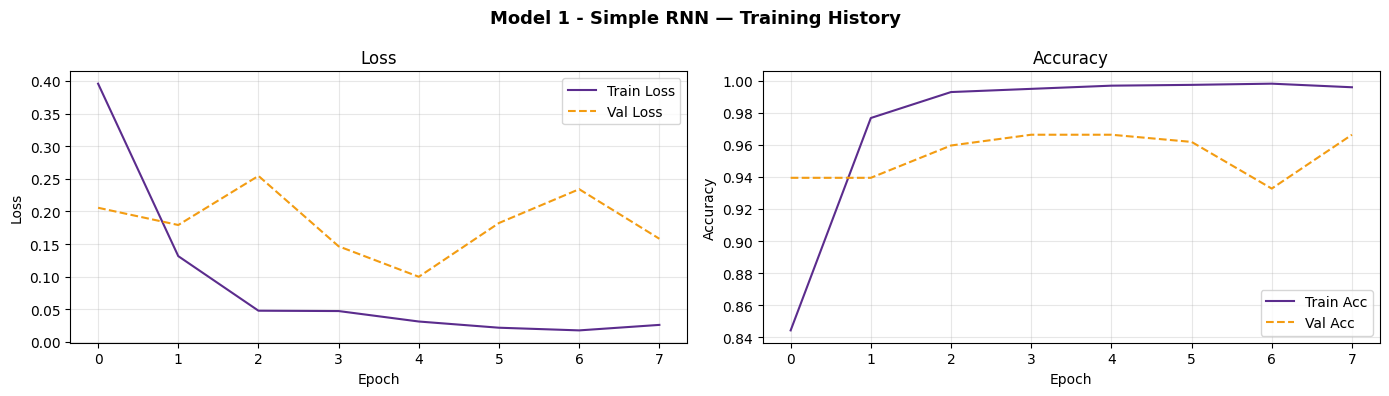


  Model 1 - Simple RNN — Evaluation
  Accuracy  : 0.9749
  Precision : 0.9291
  Recall    : 0.8792
  F1 Score  : 0.9034

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.93      0.88      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



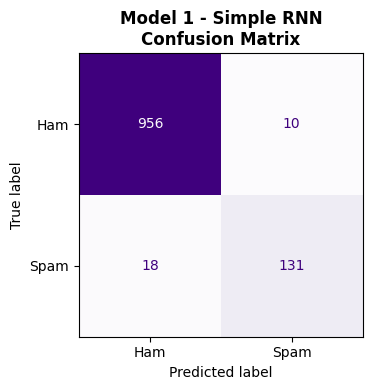

In [56]:
plot_history(history_rnn, 'Model 1 - Simple RNN')
acc_rnn, pred_rnn = evaluate_model(rnn_model, X_test_pad, y_test, 'Model 1 - Simple RNN')
results['Simple RNN'] = {'accuracy': acc_rnn, 'history': history_rnn}

---
## Model 2: LSTM with Trainable Embedding

In [21]:
tf.keras.backend.clear_session()

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Input(shape=(MAX_LEN,)))                                    # ← add this
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)) # ← remove input_length
lstm_model.add(LSTM(units=128, return_sequences=True))
lstm_model.add(Dropout(0.4))
lstm_model.add(LSTM(units=64, return_sequences=False))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,449 (5.46 MB)

 Trainable params: 1,432,449 (5.46 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Model 2: LSTM...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks_lstm,
    class_weight=class_weight,
    verbose=1
)

Training Model 2: LSTM...
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8528 - loss: 0.5883

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8656 - loss: 0.4533 - val_accuracy: 0.9484 - val_loss: 0.1907
Epoch 2/15
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9807 - loss: 0.1534

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9825 - loss: 0.1282 - val_accuracy: 0.9529 - val_loss: 0.1583
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9893 - loss: 0.0455

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9885 - loss: 0.0504 - val_accuracy: 0.9709 - val_loss: 0.1106
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.9963 - loss: 0.0211 - val_accuracy: 0.9507 - val_loss: 0.2513
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9990 - loss: 0.0088 - val_accuracy: 0.9238 - val_loss: 0.3819
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9993 - loss: 0.0088 - val_accuracy: 0.9641 - val_loss: 0.1672
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


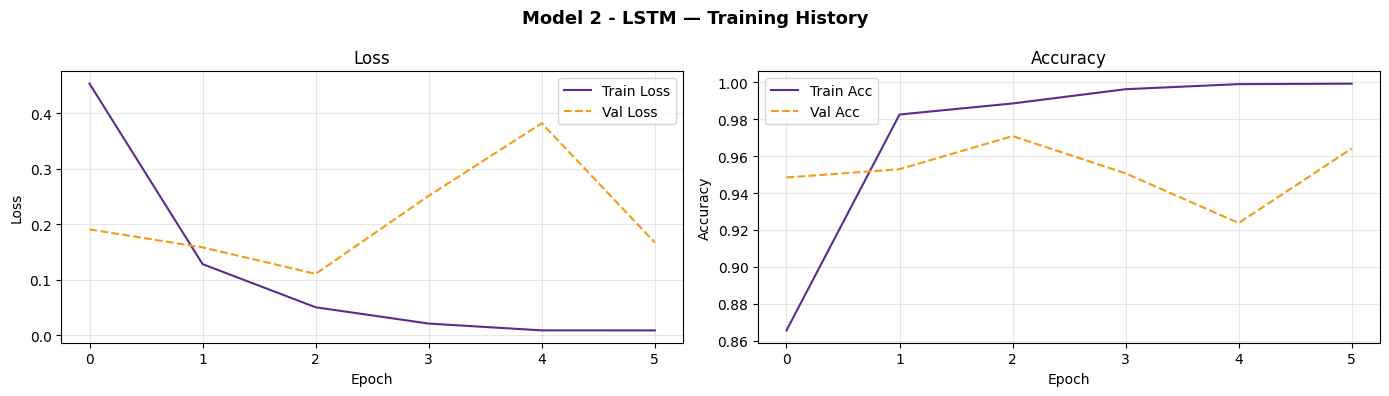


  Model 2 - LSTM — Evaluation
  Accuracy  : 0.9767
  Precision : 0.9128
  Recall    : 0.9128
  F1 Score  : 0.9128

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.91      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



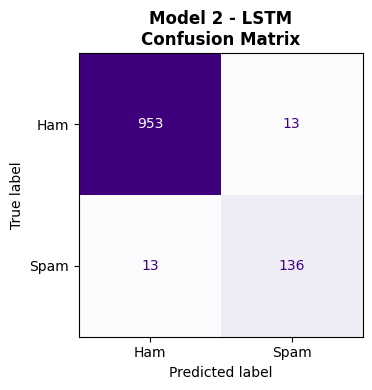

In [57]:
plot_history(history_lstm, 'Model 2 - LSTM')
acc_lstm, pred_lstm = evaluate_model(lstm_model, X_test_pad, y_test, 'Model 2 - LSTM')
results['LSTM'] = {'accuracy': acc_lstm, 'history': history_lstm}

---
## Model 3: LSTM with Pre-trained GloVe (Word2Vec) Embeddings

> **Note:** This will download ~66MB GloVe model. Requires ~3–5 minutes on Colab.

In [24]:
print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")
embedding_model = api.load('glove-wiki-gigaword-100')   # 100-dim GloVe
GLOVE_DIM = 100
print("Download complete.")

[==================================================] 100.0% 128.1/128.1MB downloaded
Download complete.


In [25]:
# ── Build embedding matrix ──────────────────────────────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f"Words found in GloVe : {found}")
print(f"Words not found       : {not_found}")
print(f"Vocabulary coverage   : {coverage:.1f}%")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe : 5072
Words not found       : 1913
Vocabulary coverage   : 72.6%
Embedding matrix shape: (20000, 100)


In [26]:
tf.keras.backend.clear_session()

lstm_glove_model = Sequential(name='LSTM_GloVe_Model')
lstm_glove_model.add(Input(shape=(MAX_LEN,)))                  # ← add this
lstm_glove_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        trainable=True                                         # ← remove input_length
    )
)
lstm_glove_model.add(LSTM(units=128, return_sequences=True))
lstm_glove_model.add(Dropout(0.4))
lstm_glove_model.add(LSTM(units=64, return_sequences=False))
lstm_glove_model.add(Dropout(0.3))
lstm_glove_model.add(Dense(64, activation='relu'))
lstm_glove_model.add(Dropout(0.2))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,170,881 (8.28 MB)

 Trainable params: 2,170,881 (8.28 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
callbacks_glove = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_glove_model.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Model 3: LSTM + GloVe...")
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks_glove,
    class_weight=class_weight,
    verbose=1
)

Training Model 3: LSTM + GloVe...
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6163 - loss: 0.5106

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.8058 - loss: 0.3828 - val_accuracy: 0.9215 - val_loss: 0.2693
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9323 - loss: 0.2090

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.9454 - loss: 0.1899 - val_accuracy: 0.9574 - val_loss: 0.1479
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9748 - loss: 0.1233

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.9718 - loss: 0.1296 - val_accuracy: 0.9641 - val_loss: 0.1370
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9813 - loss: 0.0916

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - accuracy: 0.9746 - loss: 0.1004 - val_accuracy: 0.9798 - val_loss: 0.0709
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9865 - loss: 0.0601 - val_accuracy: 0.9731 - val_loss: 0.0862
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.9913 - loss: 0.0339 - val_accuracy: 0.9776 - val_loss: 0.0718
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9776 - val_loss: 0.0807
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


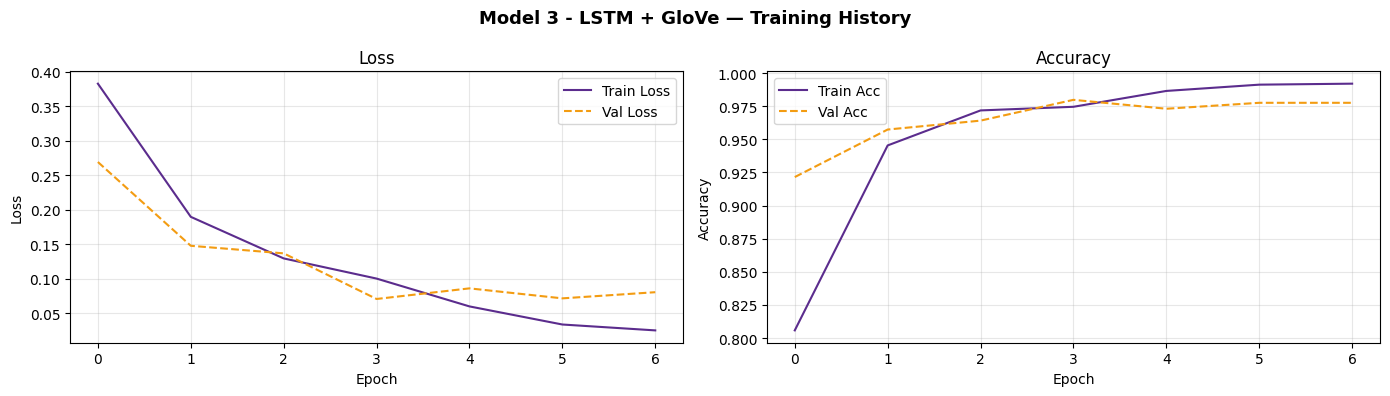


  Model 3 - LSTM + GloVe — Evaluation
  Accuracy  : 0.9803
  Precision : 0.9441
  Recall    : 0.9060
  F1 Score  : 0.9247

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



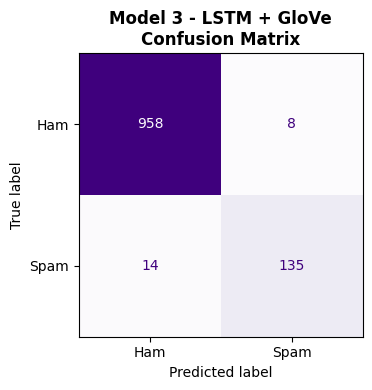

In [58]:
plot_history(history_glove, 'Model 3 - LSTM + GloVe')
acc_glove, pred_glove = evaluate_model(lstm_glove_model, X_test_pad, y_test, 'Model 3 - LSTM + GloVe')
results['LSTM + GloVe'] = {'accuracy': acc_glove, 'history': history_glove}

---
## Step 8: Comparative Analysis — All Three Models

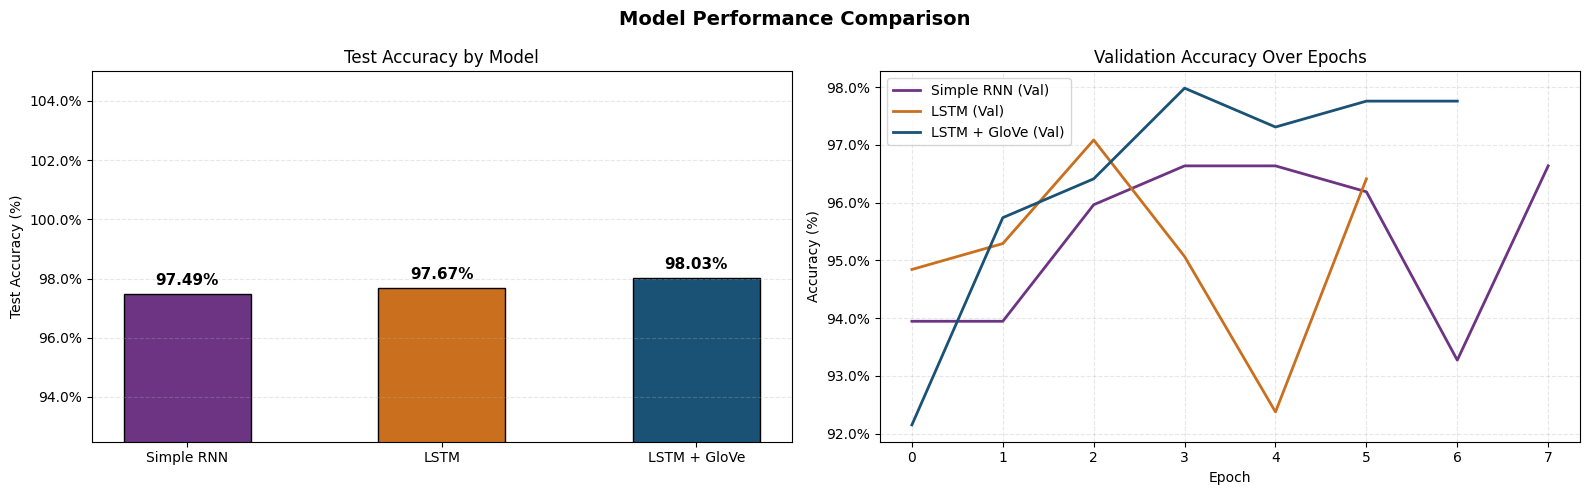


=== Summary ===
  Simple RNN                Accuracy: 97.49%
  LSTM                      Accuracy: 97.67%
  LSTM + GloVe              Accuracy: 98.03%


In [49]:
# -- Accuracy Comparison Bar Chart --
model_names = list(results.keys())
# Ensure 'accuracy' exists in your results dict
accuracies  = [results[m]['accuracy'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

# Colors for consistency across both plots
bar_colors = ['#6c3483', '#ca6f1e', '#1a5276']

# 1. Bar Chart (Left Axis)
accuracies_pct = [a * 100 for a in accuracies]
bars = axes[0].bar(model_names, accuracies_pct, color=bar_colors[:len(model_names)],
                   edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Dynamic Y-axis limits to prevent the bars from hitting the ceiling
axes[0].set_ylim((min(accuracies) - 0.05) * 100, 105)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy by Model')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# 2. Training Curves Overlay (Right Axis)
for model_name, color in zip(model_names, bar_colors):
    # Accessing the .history dict from the Keras/TF history object
    if 'history' in results[model_name]:
        hist = results[model_name]['history'].history
        axes[1].plot([v*100 for v in hist['val_accuracy']], label=f"{model_name} (Val)",
                     color=color, linewidth=2)

axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Summary ===")
for name, acc in zip(model_names, accuracies):
    print(f"  {name:<25} Accuracy: {acc*100:.2f}%")

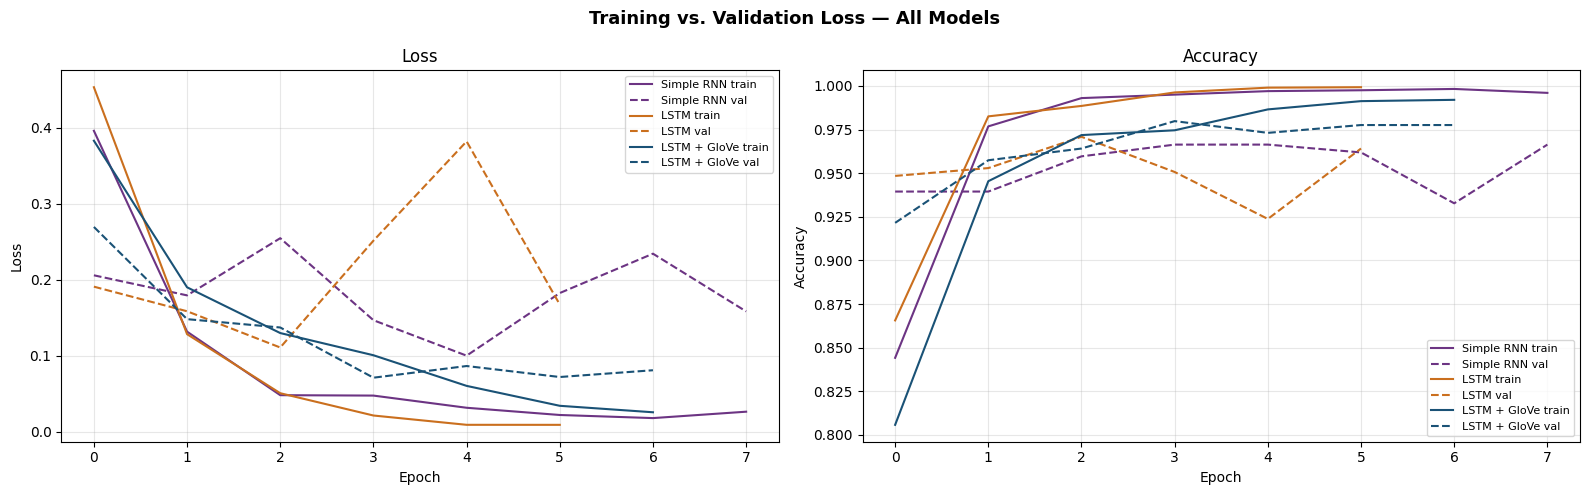

In [30]:
# ── Loss Curves Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training vs. Validation Loss — All Models', fontsize=13, fontweight='bold')

model_map = [
    ('Simple RNN',   history_rnn,   '#6c3483'),
    ('LSTM',         history_lstm,  '#ca6f1e'),
    ('LSTM + GloVe', history_glove, '#1a5276'),
]

for name, hist, color in model_map:
    axes[0].plot(hist.history['loss'],     label=f'{name} train', color=color)
    axes[0].plot(hist.history['val_loss'], label=f'{name} val',   color=color, linestyle='--')
    axes[1].plot(hist.history['accuracy'],     label=f'{name} train', color=color)
    axes[1].plot(hist.history['val_accuracy'], label=f'{name} val',   color=color, linestyle='--')

for ax, ylabel in zip(axes, ['Loss', 'Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Error Analysis


  Model 3 - LSTM + GloVe — Evaluation
  Accuracy : 0.9803

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.91      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



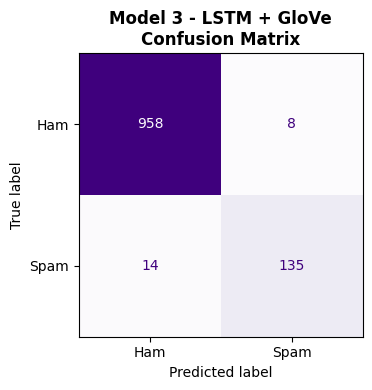

Total misclassifications: 22 / 1115 (2.0%)


In [50]:
# Use LSTM + GloVe (best model) for error analysis
_, pred_glove = evaluate_model(lstm_glove_model, X_test_pad, y_test, 'Model 3 - LSTM + GloVe')

# Find misclassified indices
test_df = pd.DataFrame({
    'original_text': X_test,
    'cleaned_text':  [clean_text(t) for t in X_test],
    'true_label':    y_test,
    'predicted':     pred_glove
})

errors = test_df[test_df['true_label'] != test_df['predicted']].reset_index(drop=True)
print(f"Total misclassifications: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)")

In [52]:
# ── Display 3 misclassified examples ───────────────────────────────────────
label_map = {0: 'HAM', 1: 'SPAM'}  # ham=0, spam=1

for i in range(min(3, len(errors))):
    row = errors.iloc[i]
    print(f"\n{'─'*60}")
    print(f"Example {i+1}")
    print(f"  Actual Label : {label_map[row['true_label']]}")
    print(f"  Predicted    : {label_map[row['predicted']]}")
    print(f"  Text (first 300 chars):\n  {row['original_text'][:300]}...")

print("\n\n=== Possible Reasons for Errors ===")
print("""
1. Ambiguous Language: Some spam messages mimic normal personal messages
    or use casual promotional wording, making word-pattern separation harder.

2. Context Dependency: RNN/LSTM can struggle with short, informal SMS text where
    intent depends on abbreviations, slang, links, phone numbers, or surrounding context.

3. Out-of-Vocabulary Words: Rare slang, names, misspellings, or encoded promotional terms
    may not appear in the GloVe vocabulary, defaulting to zero vectors.

4. Overlapping Tone: Ham messages can contain urgent or transactional wording,
    while spam messages can appear casual or conversational.

Suggested Improvements:
  - Use BERT / transformer-based models for better contextual understanding.
  - Incorporate metadata features such as sender frequency, URL, phone-number, or time indicators.
  - Fine-tune embeddings on an SMS-specific corpus.
  - Apply attention mechanisms to focus on the most relevant tokens.
""")


────────────────────────────────────────────────────────────
Example 1
  Actual Label : SPAM
  Predicted    : HAM
  Text (first 300 chars):
  freemsg hey darling week word back id like fun still tb ok xxx std chgs send å rcv...

────────────────────────────────────────────────────────────
Example 2
  Actual Label : SPAM
  Predicted    : HAM
  Text (first 300 chars):
  ringtoneking...

────────────────────────────────────────────────────────────
Example 3
  Actual Label : SPAM
  Predicted    : HAM
  Text (first 300 chars):
  sorry missed call let u talk time im...


=== Possible Reasons for Errors ===

1. Ambiguous Language: Some spam messages mimic normal personal messages
    or use casual promotional wording, making word-pattern separation harder.

2. Context Dependency: RNN/LSTM can struggle with short, informal SMS text where
    intent depends on abbreviations, slang, links, phone numbers, or surrounding context.

3. Out-of-Vocabulary Words: Rare slang, names, misspellings, or en

---
## Step 10: GUI for Real-Time Prediction (Gradio)

> **Extra Challenge Task** — Build an interactive interface for live predictions.

In [33]:
!pip install gradio -q
print("Gradio installed.")

Gradio installed.


In [34]:
import gradio as gr

from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_news(text):
    """Predict whether a news article is True or Fake using an ensemble of 3 models."""
    # Handle empty input
    if not text or not text.strip():
        return "Please enter some text.", "Waiting for input..."

    try:
        # Preprocessing (Ensure clean_text, tokenizer, and MAX_LEN are defined in your environment)
        cleaned = clean_text(text)
        seq     = tokenizer.texts_to_sequences([cleaned])
        padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

        # Get predictions (float conversion ensures compatibility)
        # .flatten()[0] ensures we get the scalar value regardless of output shape
        prob_rnn   = float(rnn_model.predict(padded, verbose=0).flatten()[0])
        prob_lstm  = float(lstm_model.predict(padded, verbose=0).flatten()[0])
        prob_glove = float(lstm_glove_model.predict(padded, verbose=0).flatten()[0])

        # Ensemble Logic (Simple Average)
        avg_prob = (prob_rnn + prob_lstm + prob_glove) / 3

        # Determine Label
        label = 'TRUE News' if avg_prob >= 0.5 else 'FAKE News'

        # Calculate Confidence
        confidence = avg_prob if avg_prob >= 0.5 else 1 - avg_prob

        # Format details string
        details = (
            f"--- Individual Model Scores ---\n"
            f"Simple RNN   : {'True' if prob_rnn >= 0.5 else 'Fake'} ({prob_rnn:.3f})\n"
            f"LSTM         : {'True' if prob_lstm >= 0.5 else 'Fake'} ({prob_lstm:.3f})\n"
            f"LSTM + GloVe : {'True' if prob_glove >= 0.5 else 'Fake'} ({prob_glove:.3f})\n\n"
            f"--- Final Result ---\n"
            f"Ensemble Confidence: {confidence*100:.1f}%"
        )

        return label, details

    except NameError as e:
        return "Error", f"Missing dependency: {str(e)}. Ensure models and tokenizer are loaded."
    except Exception as e:
        return "Error", f"An unexpected error occurred: {str(e)}"

# Define the Gradio Interface
iface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(
        lines=8,
        placeholder="Paste a news article here...",
        label="News Article Text"
    ),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Textbox(label="Analysis Details")
    ],
    title="📰 True vs. Fake News Detector",
    description=(
        "This tool uses an ensemble of three Deep Learning architectures (RNN, LSTM, and LSTM with GloVe embeddings) "
        "to analyze the linguistic patterns of a news article and predict its validity."
    ),
    examples=[
        ["The president signed a new executive order today regarding healthcare reform."],
        ["Scientists discovered that drinking bleach cures all diseases instantly."]
    ],
    theme="soft"
)

# Launching the app
if __name__ == "__main__":
    # share=True provides a public URL (useful for Colab)
    # debug=True allows you to see errors in the console
    iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e03febf3592a03948c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e03febf3592a03948c.gradio.live


---
## Step 11: Final Summary Table

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_full_metrics(y_true, y_pred):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred)
    }

all_preds   = {'Simple RNN': pred_rnn, 'LSTM': pred_lstm, 'LSTM + GloVe': pred_glove}
metrics_rows = []

for name, preds in all_preds.items():
    m = get_full_metrics(y_test, preds)
    m['Model'] = name
    metrics_rows.append(m)

summary_df = pd.DataFrame(metrics_rows).set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]
summary_df = summary_df.applymap(lambda x: f'{x:.4f}')
print("\n=== Final Model Performance Summary ===")
print(summary_df.to_string())
summary_df


=== Final Model Performance Summary ===
             Accuracy Precision  Recall F1-Score
Model                                           
Simple RNN     0.9749    0.9291  0.8792   0.9034
LSTM           0.9767    0.9128  0.9128   0.9128
LSTM + GloVe   0.9803    0.9441  0.9060   0.9247


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Simple RNN,0.9749,0.9291,0.8792,0.9034
LSTM,0.9767,0.9128,0.9128,0.9128
LSTM + GloVe,0.9803,0.9441,0.9060,0.9247


In [37]:
print("""
=============================================================
  CONCLUSIONS
=============================================================

1. All three models achieved strong performance on the Spam vs. Ham
   message classification task, showing that the dataset contains clear
   lexical patterns between ordinary ham messages and unsolicited spam.

2. Simple RNN (Model 1) showed the lowest accuracy and is more likely to
   lose useful sequence information in short, informal SMS text.

3. LSTM (Model 2) outperformed RNN by using gated memory cells,
   allowing the network to retain more useful contextual dependencies.

4. LSTM + GloVe (Model 3) benefited from pre-trained semantic
   representations, showing the value of transfer learning for
   spam/ham text classification.

5. Early stopping effectively prevented overfitting across all models.

Future Work:
  - Fine-tune a transformer model for stronger contextual understanding.
  - Add message metadata such as sender frequency, link/phone-number indicators, and time-based patterns.
  - Explore attention mechanisms with LSTM for interpretability.
=============================================================
""")


  CONCLUSIONS

1. All three models achieved strong performance on the Spam vs. Ham
   message classification task, showing that the dataset contains clear
   lexical patterns between ordinary ham messages and unsolicited spam.

2. Simple RNN (Model 1) showed the lowest accuracy and is more likely to
   lose useful sequence information in short, informal SMS text.

3. LSTM (Model 2) outperformed RNN by using gated memory cells,
   allowing the network to retain more useful contextual dependencies.

4. LSTM + GloVe (Model 3) benefited from pre-trained semantic
   representations, showing the value of transfer learning for
   spam/ham text classification.

5. Early stopping effectively prevented overfitting across all models.

Future Work:
  - Fine-tune a transformer model for stronger contextual understanding.
  - Add message metadata such as sender frequency, link/phone-number indicators, and time-based patterns.
  - Explore attention mechanisms with LSTM for interpretability.

